In [39]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [41]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.cuda.is_available())

True


In [42]:
DATASET_PATH = '/home/nfs/inf6/data/datasets/MOVi/movi_c'

In [4]:
import os 
from PIL import Image

video_id = 5 # range [0,249] for validation and up to 09736 for train
frame_id = 10 # range [0,23]
rgb_frame = f"rgb_{video_id:05d}_{frame_id:02d}.png"
print(rgb_frame)

path = os.path.join(DATASET_PATH, 'validation', rgb_frame)
img = Image.open(path).convert("RGB")
print('img size:', img.size)

rgb_00005_10.png
img size: (128, 128)


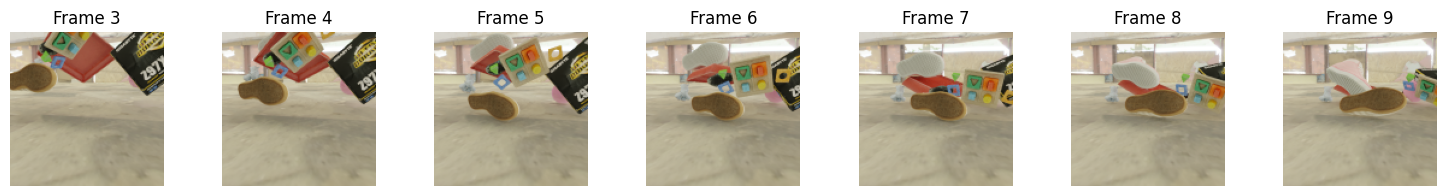

In [5]:
from utils.display_frame_sequence import display_frame_sequence

display_frame_sequence(f"{DATASET_PATH}/validation", video_id=144, num_frames=10, start_frame=3)

In [8]:
from utils.visualize_video_sample import visualize_video_sample

visualize_video_sample(data_dir=f"{DATASET_PATH}/validation", video_id=5)

ModuleNotFoundError: No module named 'imageio'

In [11]:
mask_path = f"/home/nfs/inf6/data/datasets/MOVi/movi_c/train/mask_{video_id}.pt"
mask_data = torch.load(mask_path, map_location='cpu')

print("Ключи в файле:", mask_data.keys())  # => должен быть 'masks'

masks = mask_data['masks']
print(f"Тип masks: {type(masks)}")
print(f"Количество кадров: {len(masks)}")
print(f"Размер одного кадра маски: {masks[0].shape}")
print(f"Уникальные значения в кадре {frame_idx}:", torch.unique(masks[frame_idx]))

Ключи в файле: dict_keys(['masks'])
Тип masks: <class 'torch.Tensor'>
Количество кадров: 24
Размер одного кадра маски: torch.Size([128, 128])
Уникальные значения в кадре 5: tensor([0, 1, 2, 3, 4, 5], dtype=torch.uint8)


In [16]:
list(masks)[0]

tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]], dtype=torch.uint8)

In [9]:
import torch

mask_path = "/home/nfs/inf6/data/datasets/MOVi/movi_c/train/mask_09736.pt"
mask = torch.load(mask_path, map_location="cpu")

print("Тип:", type(mask))
if isinstance(mask, dict):
    for k, v in mask.items():
        print(f"{k}: {v.shape if hasattr(v, 'shape') else type(v)}")

Тип: <class 'dict'>
masks: torch.Size([24, 128, 128])


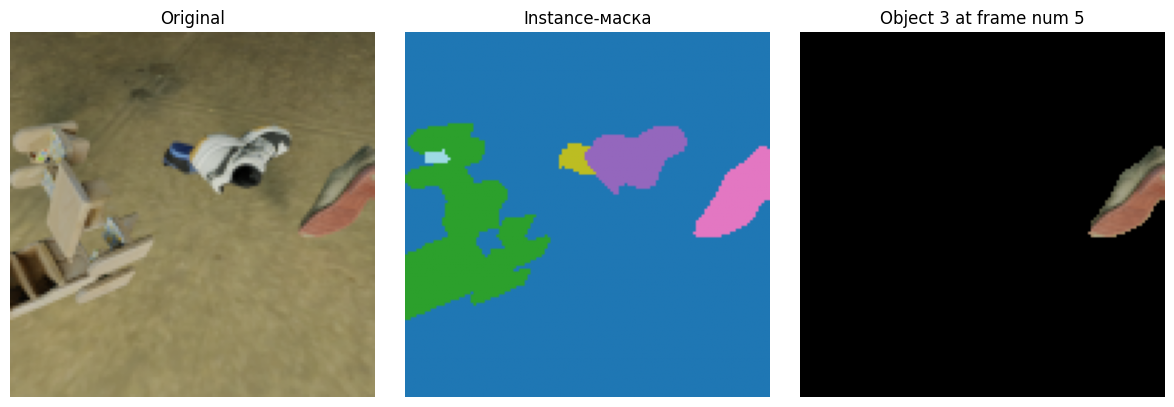

In [10]:
import torch
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

video_id = "09736"
frame_idx = 5
object_id = 3

mask_path = f"/home/nfs/inf6/data/datasets/MOVi/movi_c/train/mask_{video_id}.pt"
rgb_path = f"/home/nfs/inf6/data/datasets/MOVi/movi_c/train/rgb_{video_id}_{frame_idx:02d}.png"

# Загрузка mask и RGB
mask_data = torch.load(mask_path, map_location='cpu')
mask_frame = mask_data['masks'][frame_idx]  # shape: [128, 128]

rgb_tensor = torch.from_numpy(np.array(Image.open(rgb_path)))  # shape: [H, W, 3]

binary_mask = (mask_frame == object_id)  # shape: [H, W]
binary_mask = binary_mask.unsqueeze(-1).expand_as(rgb_tensor)  # [H, W, 3]

masked_rgb = rgb_tensor.clone()
masked_rgb[~binary_mask] = 0  # зануляем фон

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(rgb_tensor.numpy())
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask_frame.numpy(), cmap="tab20")
plt.title("Instance-маска")
plt.tight_layout()
plt.show()
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(masked_rgb.numpy())
plt.title(f"Object {object_id} at frame num {frame_idx}")
plt.axis("off")



In [52]:
from dataset import MOViC_Dataset
from torchvision import transforms
from torch.utils.data import DataLoader

# Преобразование изображений: приведение к тензору и изменение размера
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),  # приводит к [C, H, W] и нормализует до [0, 1]
])

# Создание экземпляра датасета
dataset = MOViC_Dataset(
    root_dir=DATASET_PATH+"/train",
    input_frames=5,
    target_frames=5,
    transform=transform
)

In [53]:
input_frames, target_frames = dataset[0]

print("Input shape:", input_frames.shape)    # torch.Size([5, 3, 128, 128])
print("Target shape:", target_frames.shape)  # torch.Size([5, 3, 128, 128])

Input shape: torch.Size([5, 3, 128, 128])
Target shape: torch.Size([5, 3, 128, 128])


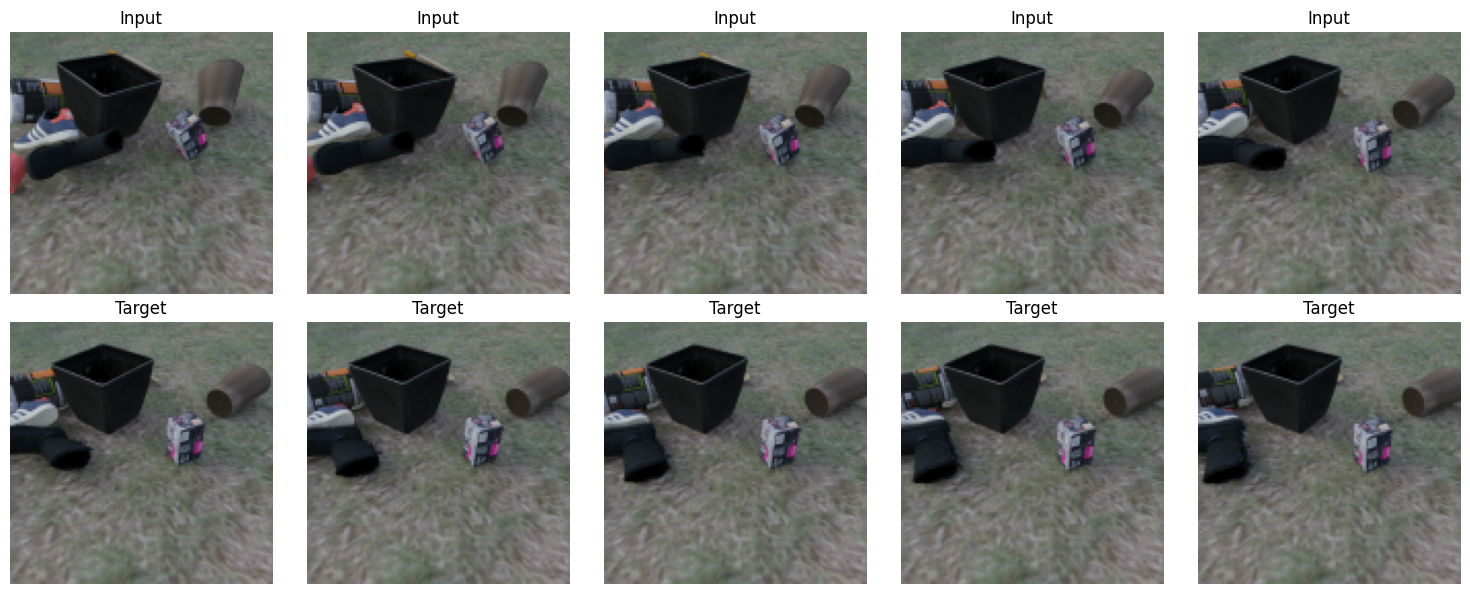

In [56]:
input_frames, target_frames = dataset[2]

all_frames = torch.cat([input_frames, target_frames], dim=0)  # [10, 3, H, W]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    img = all_frames[i].permute(1, 2, 0).numpy()  # [C,H,W] → [H,W,C]
    ax.imshow(img)
    ax.axis('off')
    ax.set_title("Input" if i < 5 else "Target")

plt.tight_layout()
plt.show()

In [45]:
from dataset import MOViC_Dataset
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# допустим, у тебя есть класс MOViC_Dataset
dataset = MOViC_Dataset(
    root_dir=DATASET_PATH,
    split="train",
    target='mask',  # или 'mask'
    img_size=(64, 64),
    input_frames=5,
    target_frames=5,
    transform=transforms.Compose([
        transforms.RandomVerticalFlip(),
        #transforms.ColorJitter(brightness=0.8, contrast=0.9)
    ])
)



torch.Size([5, 64, 64]) torch.Size([5, 64, 64])


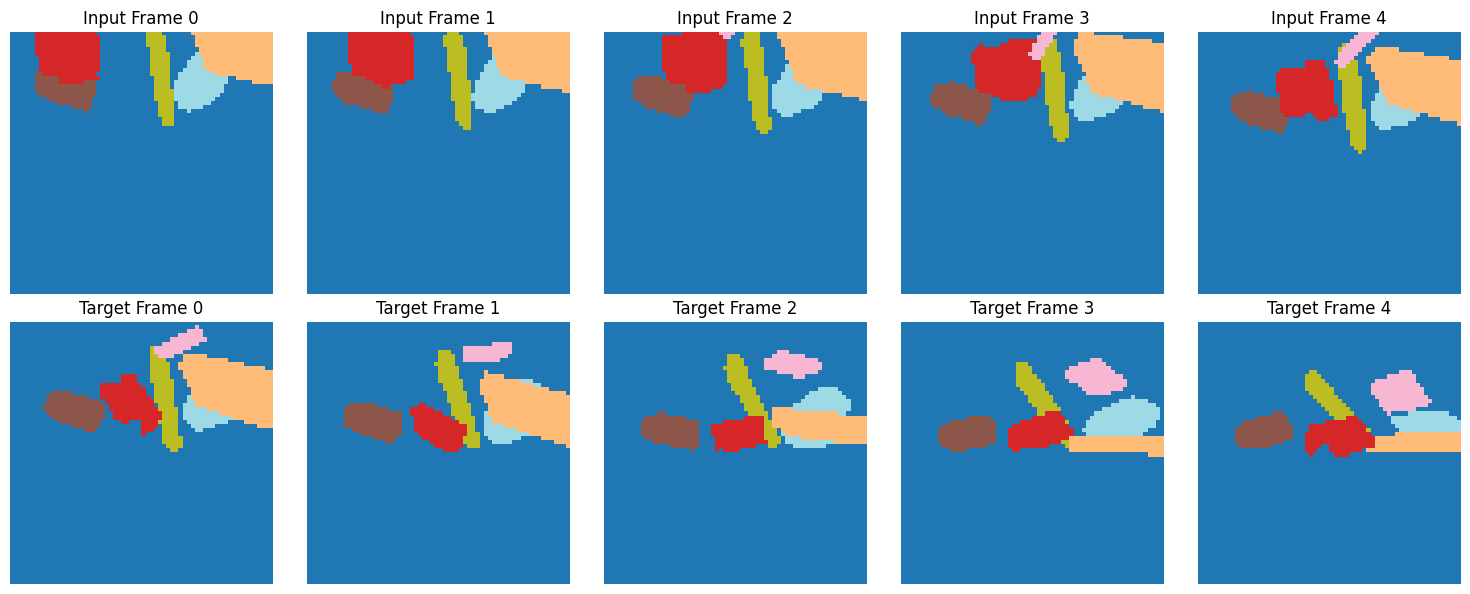

In [47]:
# Получаем пример из датасета
input_frames, target_frames = dataset[4]  # оба размера: [5, 1, H, W]

n_input = input_frames.shape[0]
n_target = target_frames.shape[0]
n_total = max(n_input, n_target)

fig, axs = plt.subplots(2, n_total, figsize=(3 * n_total, 6))

for i in range(n_total):
    # --- Input mask ---
    if i < n_input:
        mask = input_frames[i]  # [1, H, W] или [H, W]
        if mask.ndim == 3:
            mask = mask.squeeze(0)
        axs[0, i].imshow(mask.numpy(), cmap="tab20", vmin=0)
        axs[0, i].set_title(f"Input Frame {i}")
        axs[0, i].axis("off")

    # --- Target mask ---
    if i < n_target:
        mask = target_frames[i]
        if mask.ndim == 3:
            mask = mask.squeeze(0)
        axs[1, i].imshow(mask.numpy(), cmap="tab20", vmin=0)
        axs[1, i].set_title(f"Target Frame {i}")
        axs[1, i].axis("off")

plt.tight_layout()
plt.show()

In [30]:
dataset[0]

torch.Size([5, 64, 64]) torch.Size([5, 64, 64])


(tensor([[[0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          ...,
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0]],
 
         [[0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          ...,
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0]],
 
         [[0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          ...,
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0]],
 
         [[0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          ...,
          [0, 0, 2,  ..., 0, 0, 0],
          [0, 0, 2,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0]],
 
         [[0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0,

torch.Size([5, 64, 64]) torch.Size([5, 64, 64])


RuntimeError: permute(sparse_coo): number of dimensions in the tensor input does not match the length of the desired ordering of dimensions i.e. input.dim() = 2 is not equal to len(dims) = 3

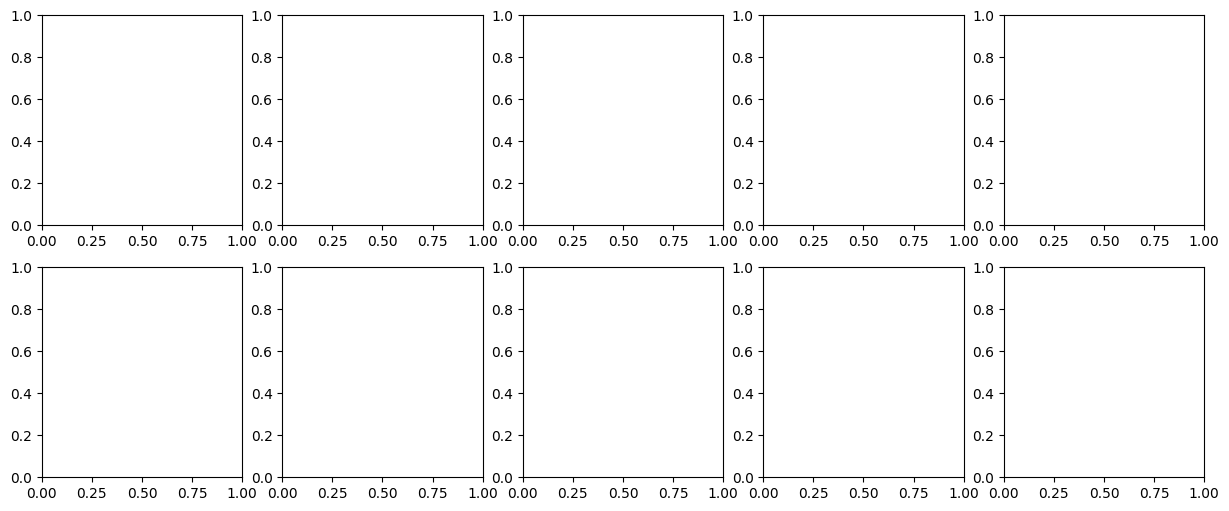

In [31]:
# взять один пример
input_frames, target_frames = dataset[4]

n_input = input_frames.shape[0]
n_target = target_frames.shape[0]
n_total = max(n_input, n_target)

fig, axs = plt.subplots(2, n_total, figsize=(3 * n_total, 6))

for i in range(n_total):
    if i < n_input:
        axs[0, i].imshow(input_frames[i].permute(1, 2, 0).numpy())
        axs[0, i].set_title(f"Input Frame {i}")
    axs[0, i].axis("off")

    if i < n_target:
        axs[1, i].imshow(target_frames[i].permute(1, 2, 0).numpy())
        axs[1, i].set_title(f"Target Frame {i}")
    axs[1, i].axis("off")

plt.tight_layout()
plt.show()